In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import cv2
import albumentations as A

In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/realwaste-main/RealWaste"

processed_dataset = "/content/drive/MyDrive/processed_waste_dataset"

organic_folder = processed_dataset + "/Organic"
recyclable_folder = processed_dataset + "/Recyclable"

In [ ]:
if os.path.exists(processed_dataset):
    shutil.rmtree(processed_dataset)

os.makedirs(organic_folder)
os.makedirs(recyclable_folder)

print("Clean dataset folders created")

Clean dataset folders created


In [ ]:
organic_classes = ["Food Organics", "Vegetation"]

for cls in organic_classes:

    src_folder = os.path.join(dataset_path, cls)

    for img in os.listdir(src_folder):

        src = os.path.join(src_folder, img)

        if os.path.isfile(src):
            shutil.copy(src, organic_folder)

print("Organic images copied")

Organic images copied


In [ ]:
recyclable_classes = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

for cls in recyclable_classes:

    src_folder = os.path.join(dataset_path, cls)

    for img in os.listdir(src_folder):

        src = os.path.join(src_folder, img)

        if os.path.isfile(src):
            shutil.copy(src, recyclable_folder)

print("Recyclable images copied")

Recyclable images copied


In [ ]:
print("Organic:", len(os.listdir(organic_folder)))
print("Recyclable:", len(os.listdir(recyclable_folder)))

Organic: 2954
Recyclable: 3092


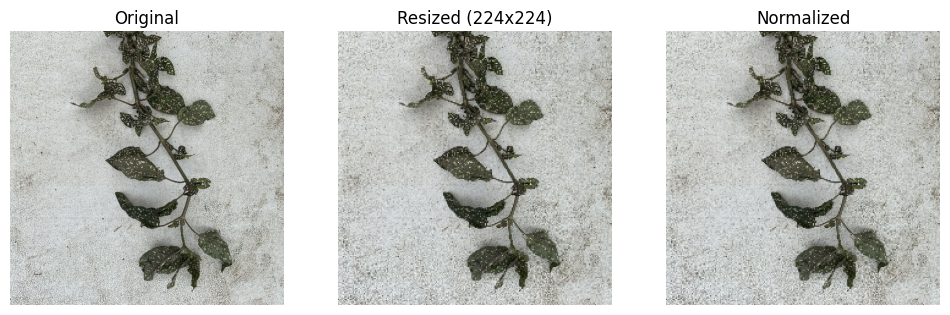

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

# pick one image from organic folder
sample_img_path = os.path.join(organic_folder, random.choice(os.listdir(organic_folder)))

# read using cv2
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# resize
img_resized = cv2.resize(img_rgb, (224, 224))

# normalize
img_normalized = img_resized / 255.0

# plot
fig, axes = plt.subplots(1, 3, figsize=(12,4))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_resized)
axes[1].set_title("Resized (224x224)")
axes[1].axis("off")

axes[2].imshow(img_normalized)
axes[2].set_title("Normalized")
axes[2].axis("off")

plt.show()

In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=30, p=0.7),
    A.RandomBrightnessContrast(p=0.5)
])

target = 2954
count = 0

while len(os.listdir(organic_folder)) < target:

    for img_name in os.listdir(organic_folder):

        img_path = os.path.join(organic_folder, img_name)

        image = cv2.imread(img_path)

        if image is None:
            continue

        augmented = transform(image=image)
        aug_image = augmented["image"]

        new_name = f"aug_{count}_{img_name}"

        cv2.imwrite(
            os.path.join(organic_folder, new_name),
            aug_image
        )

        count += 1

        if 2954 >= target:
            break

print("Dataset balanced")

Dataset balanced


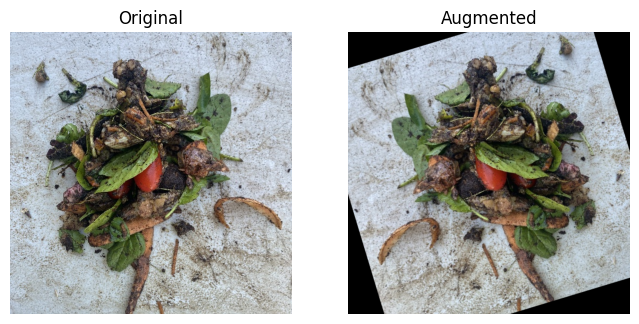

In [ ]:
# show augmentation effect

sample_img_path = os.path.join(organic_folder, random.choice(os.listdir(organic_folder)))

img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

augmented = transform(image=img)
aug_img = augmented["image"]
aug_img_rgb = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")

axes[1].imshow(aug_img_rgb)
axes[1].set_title("Augmented")

for ax in axes:
    ax.axis("off")

plt.show()

In [ ]:
print("Organic:", len(os.listdir(organic_folder)))
print("Recyclable:", len(os.listdir(recyclable_folder)))

Organic: 2954
Recyclable: 3092


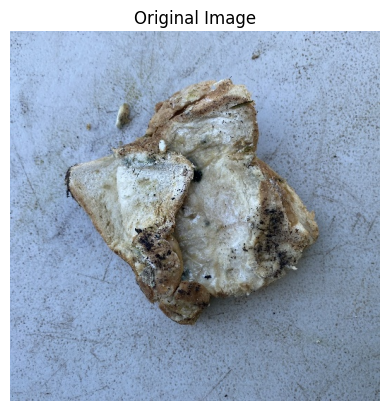

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/processed_waste_dataset/Organic/Food Organics_108.jpg")

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(processed_dataset, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
dataset = datasets.ImageFolder(processed_dataset, transform=transform)

print("Updated Total Images:", len(dataset))

Updated Total Images: 6046


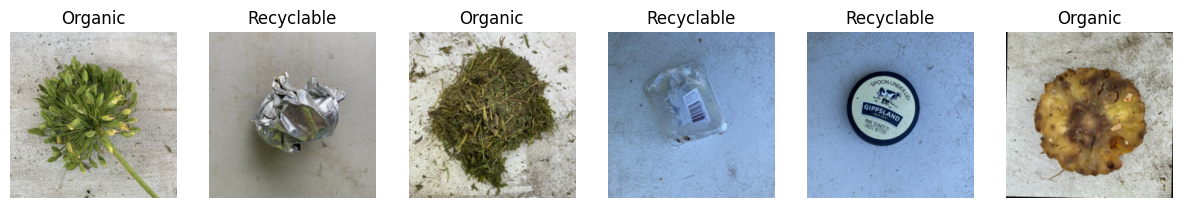

In [ ]:
#show batch images

images, labels = next(iter(train_loader))

images = images[:6]
labels = labels[:6]

fig, axes = plt.subplots(1,6, figsize=(15,4))

classes = ["Organic", "Recyclable"]

for i in range(6):
    img = images[i].permute(1,2,0)
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis("off")

plt.show()

In [ ]:
def train_with_early_stopping(model, train_loader, optimizer, criterion,
                             epochs=10, patience=2, name="model"):

    best_loss = float('inf')
    counter = 0

    model = model.to(device)

    for epoch in range(epochs):

        print(f"\n {name} Starting Epoch {epoch+1}")

        model.train()
        running_loss = 0

        for i, (images, labels) in enumerate(train_loader):

            if i % 50 == 0:
                print(f"{name} Processing batch {i}")

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        print(f"{name} Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

        # Early stopping
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            counter = 0
            torch.save(model.state_dict(), f"{name}_best.pth")
            print(f"{name}Improved, model saved")
        else:
            counter += 1
            print(f"{name}No improvement ({counter}/{patience})")

        if counter >= patience:
            print(f"{name}Early stopping triggered")
            break

    return model

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

# Only train final layer
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

resnet = train_with_early_stopping(
    resnet,
    train_loader,
    optimizer,
    criterion,
    epochs=10,
    patience=2,
    name="ResNet"
)


 ResNet Starting Epoch 1
ResNet Processing batch 0
ResNet Processing batch 50
ResNet Processing batch 100
ResNet Epoch 1, Loss: 0.4237
ResNetImproved, model saved

 ResNet Starting Epoch 2
ResNet Processing batch 0
ResNet Processing batch 50
ResNet Processing batch 100
ResNet Epoch 2, Loss: 0.2204
ResNetImproved, model saved

 ResNet Starting Epoch 3
ResNet Processing batch 0
ResNet Processing batch 50
ResNet Processing batch 100
ResNet Epoch 3, Loss: 0.1644
ResNetImproved, model saved

 ResNet Starting Epoch 4
ResNet Processing batch 0
ResNet Processing batch 50
ResNet Processing batch 100
ResNet Epoch 4, Loss: 0.1341
ResNetImproved, model saved

 ResNet Starting Epoch 5
ResNet Processing batch 0
ResNet Processing batch 50
ResNet Processing batch 100
ResNet Epoch 5, Loss: 0.1124
ResNetImproved, model saved

 ResNet Starting Epoch 6
ResNet Processing batch 0
ResNet Processing batch 50
ResNet Processing batch 100
ResNet Epoch 6, Loss: 0.0958
ResNetImproved, model saved

 ResNet Startin

In [ ]:
from torchvision.models import densenet121, DenseNet121_Weights

densenet = densenet121(weights=DenseNet121_Weights.DEFAULT)

# Freeze all layers
for param in densenet.parameters():
    param.requires_grad = False

# Replace classifier
densenet.classifier = nn.Linear(densenet.classifier.in_features, 2)

# Only train classifier
optimizer = torch.optim.Adam(densenet.classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

densenet = train_with_early_stopping(
    densenet,
    train_loader,
    optimizer,
    criterion,
    epochs=10,
    patience=2,
    name="DenseNet"
)


 DenseNet Starting Epoch 1
DenseNet Processing batch 0
DenseNet Processing batch 50
DenseNet Processing batch 100
DenseNet Epoch 1, Loss: 0.4172
DenseNetImproved, model saved

 DenseNet Starting Epoch 2
DenseNet Processing batch 0
DenseNet Processing batch 50
DenseNet Processing batch 100
DenseNet Epoch 2, Loss: 0.2302
DenseNetImproved, model saved

 DenseNet Starting Epoch 3
DenseNet Processing batch 0
DenseNet Processing batch 50
DenseNet Processing batch 100
DenseNet Epoch 3, Loss: 0.1712
DenseNetImproved, model saved

 DenseNet Starting Epoch 4
DenseNet Processing batch 0
DenseNet Processing batch 50
DenseNet Processing batch 100
DenseNet Epoch 4, Loss: 0.1401
DenseNetImproved, model saved

 DenseNet Starting Epoch 5
DenseNet Processing batch 0
DenseNet Processing batch 50
DenseNet Processing batch 100
DenseNet Epoch 5, Loss: 0.1176
DenseNetImproved, model saved

 DenseNet Starting Epoch 6
DenseNet Processing batch 0
DenseNet Processing batch 50
DenseNet Processing batch 100
Dense

In [ ]:
class ECCDNNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.dense = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
        self.res = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # Remove classifiers
        self.dense.classifier = nn.Identity()
        self.res.fc = nn.Identity()

        # Better classifier (VERY IMPORTANT)
        self.fc = nn.Sequential(
            nn.Linear(1024 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        f1 = self.dense(x)
        f2 = self.res(x)
        return self.fc(torch.cat((f1, f2), dim=1))


eccdn = ECCDNNet()

# Don't freeze everything
# Freeze MOST, but allow last layers to learn

for param in eccdn.dense.parameters():
    param.requires_grad = False

for param in eccdn.res.parameters():
    param.requires_grad = False

# UNFREEZE LAST BLOCKS (CRITICAL)
for param in eccdn.dense.features[-1].parameters():
    param.requires_grad = True

for param in eccdn.res.layer4.parameters():
    param.requires_grad = True

# Lower LR for fine-tuning
optimizer = torch.optim.Adam(eccdn.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

eccdn = train_with_early_stopping(
    eccdn,
    train_loader,
    optimizer,
    criterion,
    epochs=10,
    patience=2,
    name="ECCDN"
)


 ECCDN Starting Epoch 1
ECCDN Processing batch 0
ECCDN Processing batch 50
ECCDN Processing batch 100
ECCDN Epoch 1, Loss: 0.3091
ECCDNImproved, model saved

 ECCDN Starting Epoch 2
ECCDN Processing batch 0
ECCDN Processing batch 50
ECCDN Processing batch 100
ECCDN Epoch 2, Loss: 0.0939
ECCDNImproved, model saved

 ECCDN Starting Epoch 3
ECCDN Processing batch 0
ECCDN Processing batch 50
ECCDN Processing batch 100
ECCDN Epoch 3, Loss: 0.0428
ECCDNImproved, model saved

 ECCDN Starting Epoch 4
ECCDN Processing batch 0
ECCDN Processing batch 50
ECCDN Processing batch 100
ECCDN Epoch 4, Loss: 0.0270
ECCDNImproved, model saved

 ECCDN Starting Epoch 5
ECCDN Processing batch 0
ECCDN Processing batch 50
ECCDN Processing batch 100
ECCDN Epoch 5, Loss: 0.0212
ECCDNImproved, model saved

 ECCDN Starting Epoch 6
ECCDN Processing batch 0
ECCDN Processing batch 50
ECCDN Processing batch 100
ECCDN Epoch 6, Loss: 0.0118
ECCDNImproved, model saved

 ECCDN Starting Epoch 7
ECCDN Processing batch 0
EC

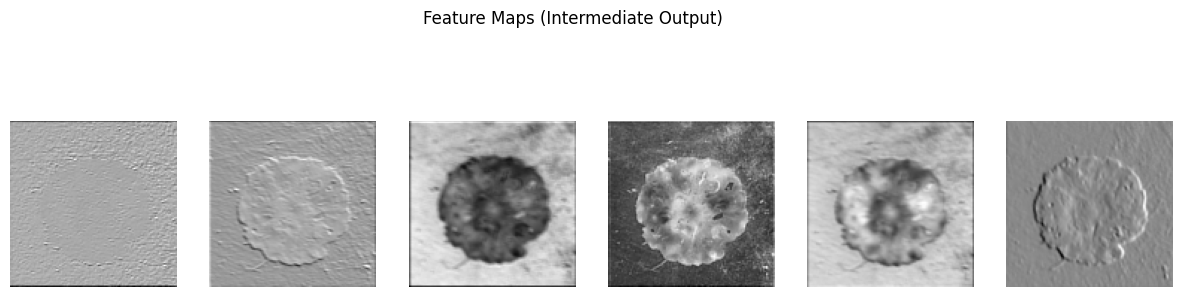

In [ ]:
# FEATURE MAP from ResNet first layer

model.eval()

# take one image
img, _ = dataset[0]
img = img.unsqueeze(0).to(device)

# get feature map
with torch.no_grad():
  #Extract intermediate features
    feature_map = model.resnet.conv1(img)

feature_map = feature_map.cpu()

# show first 6 feature maps
fig, axes = plt.subplots(1,6, figsize=(15,4))

for i in range(6):
    axes[i].imshow(feature_map[0,i], cmap='gray')
    axes[i].axis("off")

plt.suptitle("Feature Maps (Intermediate Output)")
plt.show()

In [ ]:
def evaluate(model):

    model.eval()
    correct = total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs,1)

            total += labels.size(0)
            correct += (preds==labels).sum().item()

    return 100*correct/total

In [ ]:
acc_res = evaluate(resnet)
acc_dense = evaluate(densenet)
acc_eccdn = evaluate(eccdn)

print("ResNet:", acc_res)
print("DenseNet:", acc_dense)
print("ECCDN:", acc_eccdn)

ResNet: 98.01652892561984
DenseNet: 98.84297520661157
ECCDN: 99.50413223140495


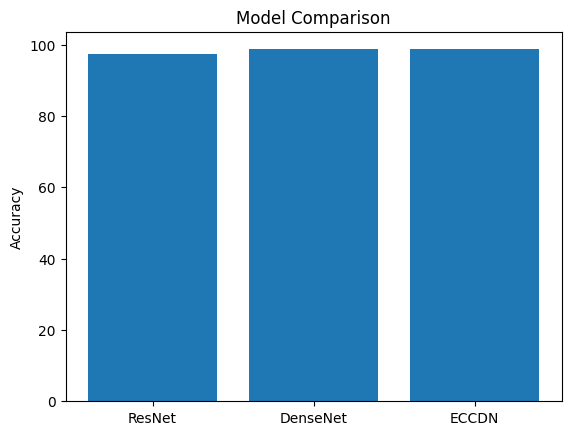

In [ ]:
 import matplotlib.pyplot as plt

plt.bar(["ResNet","DenseNet","ECCDN"], [acc_res,acc_dense,acc_eccdn])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

(np.float64(-0.5), np.float64(111.5), np.float64(111.5), np.float64(-0.5))

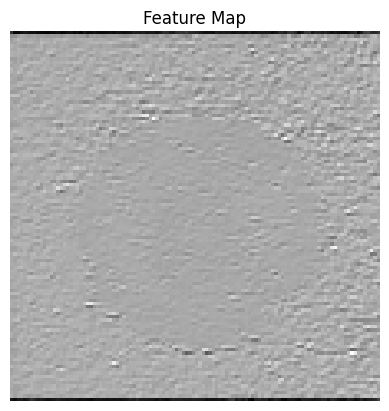

In [ ]:
img, _ = dataset[0]
img = img.unsqueeze(0).to(device)

with torch.no_grad():
    fmap = resnet.conv1(img)

plt.imshow(fmap[0,0].cpu(), cmap='gray')
plt.title("Feature Map")
plt.axis("off")

In [ ]:
import numpy as np
import cv2

def create_multi(paths):

    imgs = [cv2.resize(cv2.imread(p),(300,300)) for p in paths]

    return np.vstack((np.hstack((imgs[0],imgs[1])),
                      np.hstack((imgs[2],imgs[3]))))

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/multi.jpg: 640x640 1 cup, 1 pizza, 1 donut, 1 dining table, 1 toilet, 7.7ms
Speed: 2.5ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


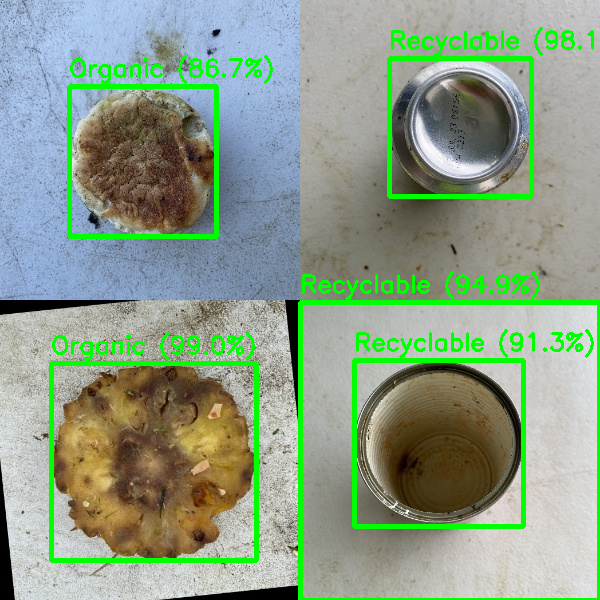

In [ ]:
# create multi image
organic_folder = processed_dataset + "/Organic"
recyclable_folder = processed_dataset + "/Recyclable"

# pick 2 organic + 2 recyclable
organic_imgs = random.sample(os.listdir(organic_folder), 2)
recyclable_imgs = random.sample(os.listdir(recyclable_folder), 2)

# combine
paths = (
    [os.path.join(organic_folder, i) for i in organic_imgs] +
    [os.path.join(recyclable_folder, i) for i in recyclable_imgs]
)

# shuffle so mix looks natural
random.shuffle(paths)

multi = create_multi(paths)
cv2.imwrite("multi.jpg", multi)

# run YOLO
results = yolo("multi.jpg")

img = cv2.imread("multi.jpg")

eccdn.eval()

for result in results:

    boxes = result.boxes

    if boxes is not None:

        for box in boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            crop = img[y1:y2, x1:x2]

            crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

            img_tensor = transform(crop_pil).unsqueeze(0).to(device)

            with torch.no_grad():
                output = eccdn(img_tensor)
                probs = torch.nn.functional.softmax(output, dim=1)
                confidence, pred = torch.max(probs, 1)

            classes = ["Organic", "Recyclable"]
            label = f"{classes[pred.item()]} ({confidence.item()*100:.1f}%)"

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
            cv2.putText(img, label, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

cv2_imshow(img)